# Analise dos atributos booleanos - imoveis_fortaleza_100p

Este notebook mede a porcentagem de valores `False` nas colunas booleanas do arquivo `imoveis_fortaleza_100p.csv`.

Objetivo: verificar se os atributos extraidos pelo scraping estao vindo majoritariamente como `False`.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

candidates = [
    Path('scraping/imov-scraper-v1/saida/imoveis_fortaleza_100p.csv'),
    Path('../scraping/imov-scraper-v1/saida/imoveis_fortaleza_100p.csv'),
]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('Nao encontrei scraping/imov-scraper-v1/saida/imoveis_fortaleza_100p.csv')

df = pd.read_csv(csv_path)

print(f'Arquivo: {csv_path.resolve()}')
print(f'Linhas: {df.shape[0]:,}'.replace(',', '.'))
print(f'Colunas: {df.shape[1]}')
df.head()

Arquivo: C:\Users\andriel_orbi\Tiago\git\pipeline-de-modelos-preditores-de-precos-de-imoveis-com-dados-em-tempo-real\scraping\imov-scraper-v1\saida\imoveis_fortaleza_100p.csv
Linhas: 5.490
Colunas: 37


,external_id,site,finalidade,tipo,titulo,preco,preco_m2,area_m2,quartos,banheiros,vagas,suites,andar,numero_endereco,bairro,cidade,estado,condominio,iptu,endereco,descricao,portaria,vista_mar,condominio_fechado,piscina,deck,varanda_gourmet,varanda,academia,salao_festa,salao_jogos,quadra_campo,latitude,longitude,is_lancamento,data_coleta,url
0,olx_olx_dom_96765635241966,OLX,venda,casa,"Vendo duas casas, bairro aerolandia, rua sete ...",60000.0,NaN,NaN,2.0,1.0,NaN,NaN,NaN,NaN,Aerolândia,Fortaleza,CE,NaN,NaN,"Rua Sete Estrelas Aerolândia, Fortaleza, CE, 6...",NaN,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,2026-06-21T03:52:50+00:00,https://ce.olx.com.br/fortaleza-e-regiao/imove...
1,olx_olx_dom_113506455334865,OLX,venda,casa,CASA MARACANAÚ ALTO ALEGRE,80000.0,3200.0,25.0,2.0,1.0,0.0,NaN,NaN,NaN,Aerolândia,Fortaleza,CE,NaN,NaN,Rua Capitão Vasconcelos - de 886/887 ao fim Ae...,Casa bem localizada no alto Alegre ótima área ...,False,False,False,False,False,False,True,False,False,False,False,NaN,NaN,False,2026-06-21T03:45:16+00:00,https://ce.olx.com.br/fortaleza-e-regiao/imove...
2,olx_olx_dom_267088036807809,OLX,venda,casa,CASA NA AEROLANDIA A VENDA,82000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aerolândia,Fortaleza,CE,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,2026-06-21T03:51:56+00:00,https://ce.olx.com.br/fortaleza-e-regiao/imove...
3,olx_olx_dom_62618018100804,OLX,venda,casa,Casa na Aerolãndia,125000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Aerolândia,Fortaleza,CE,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,2026-06-21T03:47:57+00:00,https://ce.olx.com.br/fortaleza-e-regiao/imove...
4,olx_olx_dom_161244745788907,OLX,venda,casa,Comércio/Casa na Aerolândia,200000.0,4000.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,Aerolândia,Fortaleza,CE,NaN,NaN,NaN,NaN,False,False,False,False,False,False,False,False,False,False,False,NaN,NaN,False,2026-06-21T03:49:40+00:00,https://ce.olx.com.br/fortaleza-e-regiao/imove...


In [9]:
df.count()

external_id           5490
site                  5490
finalidade            5490
tipo                  5490
titulo                5490
preco                 5490
preco_m2              5256
area_m2               5256
quartos               1214
banheiros               37
vagas                   50
suites                 740
andar                   91
numero_endereco          0
bairro                5490
cidade                5490
estado                5490
condominio               1
iptu                     1
endereco                 5
descricao                4
portaria              5490
vista_mar             5490
condominio_fechado    5490
piscina               5490
deck                  5490
varanda_gourmet       5490
varanda               5490
academia              5490
salao_festa           5490
salao_jogos           5490
quadra_campo          5490
latitude                 0
longitude                0
is_lancamento         5490
data_coleta           5490
url                   5490
d

## Colunas booleanas detectadas

A celula abaixo detecta automaticamente colunas do tipo booleano ou colunas textuais que contenham apenas `true/false`, alem de nulos.

In [4]:
def is_bool_like(series: pd.Series) -> bool:
    if pd.api.types.is_bool_dtype(series):
        return True
    values = (
        series.dropna()
        .astype(str)
        .str.strip()
        .str.lower()
        .unique()
        .tolist()
    )
    return bool(values) and set(values).issubset({'true', 'false'})

bool_cols = [col for col in df.columns if is_bool_like(df[col])]
bool_cols

['portaria',
 'vista_mar',
 'condominio_fechado',
 'piscina',
 'deck',
 'varanda_gourmet',
 'varanda',
 'academia',
 'salao_festa',
 'salao_jogos',
 'quadra_campo',
 'is_lancamento']

## Porcentagem de `False` por atributo

A tabela mostra, para cada coluna booleana, quantos registros estao como `False`, `True` ou nulos.

In [5]:
def normalize_bool(series: pd.Series) -> pd.Series:
    if pd.api.types.is_bool_dtype(series):
        return series.astype('boolean')
    mapped = series.astype(str).str.strip().str.lower().map({'true': True, 'false': False})
    return mapped.astype('boolean')

total = len(df)
rows = []

for col in bool_cols:
    s = normalize_bool(df[col])
    false_count = int((s == False).sum())
    true_count = int((s == True).sum())
    null_count = int(s.isna().sum())
    rows.append({
        'atributo': col,
        'total_linhas': total,
        'false_count': false_count,
        'false_pct': false_count / total * 100,
        'true_count': true_count,
        'true_pct': true_count / total * 100,
        'null_count': null_count,
        'null_pct': null_count / total * 100,
    })

false_summary = (
    pd.DataFrame(rows)
    .sort_values(['false_pct', 'atributo'], ascending=[False, True])
    .reset_index(drop=True)
)

false_summary.style.format({
    'false_pct': '{:.2f}%',
    'true_pct': '{:.2f}%',
    'null_pct': '{:.2f}%',
})

,atributo,total_linhas,false_count,false_pct,true_count,true_pct,null_count,null_pct
0,portaria,5490,5490,100.00%,0,0.00%,0,0.00%
1,condominio_fechado,5490,5489,99.98%,1,0.02%,0,0.00%
2,deck,5490,5489,99.98%,1,0.02%,0,0.00%
3,salao_jogos,5490,5489,99.98%,1,0.02%,0,0.00%
4,varanda_gourmet,5490,5489,99.98%,1,0.02%,0,0.00%
5,academia,5490,5488,99.96%,2,0.04%,0,0.00%
6,piscina,5490,5488,99.96%,2,0.04%,0,0.00%
7,varanda,5490,5488,99.96%,2,0.04%,0,0.00%
8,vista_mar,5490,5488,99.96%,2,0.04%,0,0.00%
9,quadra_campo,5490,5487,99.95%,3,0.05%,0,0.00%


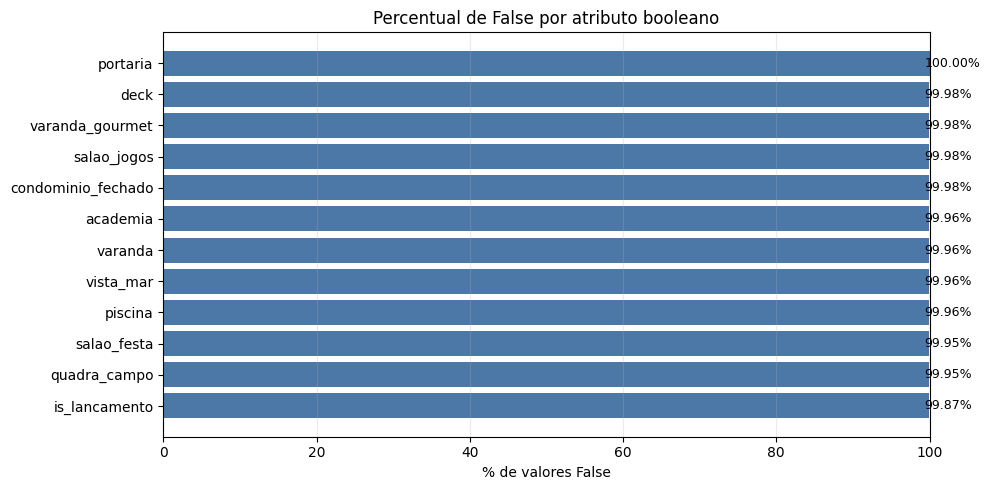

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

plot_data = false_summary.sort_values('false_pct')
ax.barh(plot_data['atributo'], plot_data['false_pct'], color='#4C78A8')
ax.set_xlim(0, 100)
ax.set_xlabel('% de valores False')
ax.set_title('Percentual de False por atributo booleano')
ax.grid(axis='x', alpha=0.25)

for i, value in enumerate(plot_data['false_pct']):
    ax.text(min(value + 0.15, 99.3), i, f'{value:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## Recorte por site

Esta visao ajuda a identificar se algum portal esta preenchendo melhor os atributos booleanos do que os outros.

In [7]:
site_rows = []

for site, group in df.groupby('site', dropna=False):
    for col in bool_cols:
        s = normalize_bool(group[col])
        site_rows.append({
            'site': site,
            'atributo': col,
            'linhas_site': len(group),
            'false_count': int((s == False).sum()),
            'false_pct': float((s == False).mean() * 100),
            'true_count': int((s == True).sum()),
            'true_pct': float((s == True).mean() * 100),
            'null_count': int(s.isna().sum()),
        })

false_by_site = pd.DataFrame(site_rows).sort_values(['site', 'false_pct', 'atributo'], ascending=[True, False, True])

false_by_site.style.format({
    'false_pct': '{:.2f}%',
    'true_pct': '{:.2f}%',
})

,site,atributo,linhas_site,false_count,false_pct,true_count,true_pct,null_count
2,ImovelWeb,condominio_fechado,27,27,100.00%,0,0.00%,0
11,ImovelWeb,is_lancamento,27,27,100.00%,0,0.00%,0
0,ImovelWeb,portaria,27,27,100.00%,0,0.00%,0
1,ImovelWeb,vista_mar,27,27,100.00%,0,0.00%,0
7,ImovelWeb,academia,27,26,96.30%,1,3.70%,0
4,ImovelWeb,deck,27,26,96.30%,1,3.70%,0
3,ImovelWeb,piscina,27,26,96.30%,1,3.70%,0
10,ImovelWeb,quadra_campo,27,26,96.30%,1,3.70%,0
8,ImovelWeb,salao_festa,27,26,96.30%,1,3.70%,0
9,ImovelWeb,salao_jogos,27,26,96.30%,1,3.70%,0


## Atributos com maior preenchimento positivo

Como quase tudo esta `False`, esta tabela ordena pelo percentual de `True` para mostrar quais atributos tiveram algum sinal positivo.

In [8]:
true_summary = false_summary.sort_values(['true_pct', 'atributo'], ascending=[False, True]).reset_index(drop=True)

true_summary[['atributo', 'true_count', 'true_pct', 'false_count', 'false_pct']].style.format({
    'true_pct': '{:.3f}%',
    'false_pct': '{:.3f}%',
})

,atributo,true_count,true_pct,false_count,false_pct
0,is_lancamento,7,0.128%,5483,99.872%
1,quadra_campo,3,0.055%,5487,99.945%
2,salao_festa,3,0.055%,5487,99.945%
3,academia,2,0.036%,5488,99.964%
4,piscina,2,0.036%,5488,99.964%
5,varanda,2,0.036%,5488,99.964%
6,vista_mar,2,0.036%,5488,99.964%
7,condominio_fechado,1,0.018%,5489,99.982%
8,deck,1,0.018%,5489,99.982%
9,salao_jogos,1,0.018%,5489,99.982%


## Diagnostico rapido

Se os percentuais de `False` ficarem proximos de 100%, isso normalmente indica uma destas possibilidades:

- os anuncios realmente nao informam esses atributos;
- o scraper nao esta encontrando esses textos/elementos nas paginas de detalhe;
- os nomes usados na deteccao dos atributos estao restritos demais;
- parte dos atributos aparece em imagens, icones ou listas renderizadas de forma diferente por site.